In [35]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END


In [37]:
class AgentState(TypedDict):
    operation:str
    number1:int
    number2:int
    number3:int
    number4:int
    final_number1:int
    final_number2:int

    

In [39]:
def adder1(state:AgentState)->AgentState:
    state['final_number1']=state['number1']+state['number2']
    return state

def subtractor1(state:AgentState)->AgentState:
    state['final_number1']=state['number1']-state['number2']
    return state

In [40]:
def adder2(state:AgentState)->AgentState:
    state['final_number2']=state['number3']+state['number4']
    return state

def subtractor2(state:AgentState)->AgentState:
    state['final_number2']=state['number3']-state['number4']
    return state

In [41]:
def decide_next_node(state:AgentState)->AgentState:
    if state['operation']=="+":
        return "addition_operation"
    elif state['operation']=="-":
        return 'substraction_operation'


        

In [42]:
graph=StateGraph(AgentState)
graph.add_node('add_node1', adder1)
graph.add_node('subtract_node1', subtractor1)
graph.add_node('router1', lambda state:state)

graph.add_node('add_node2', adder2)
graph.add_node('subtract_node2', subtractor2)
graph.add_node('router2', lambda state:state)

graph.add_edge(START, 'router1')
graph.add_conditional_edges(
    'router1', decide_next_node,
    {
        'addition_operation': 'add_node1',
        'substraction_operation': 'subtract_node1' 
    }
)
graph.add_edge('add_node1', 'router2')
graph.add_edge('subtract_node1', 'router2')
graph.add_conditional_edges(
    'router2', decide_next_node,
    {
        'addition_operation': 'add_node2',
        'substraction_operation': 'subtract_node2' 
    }
)
graph.add_edge('add_node2', END)
graph.add_edge('subtract_node2', END)
app=graph.compile()



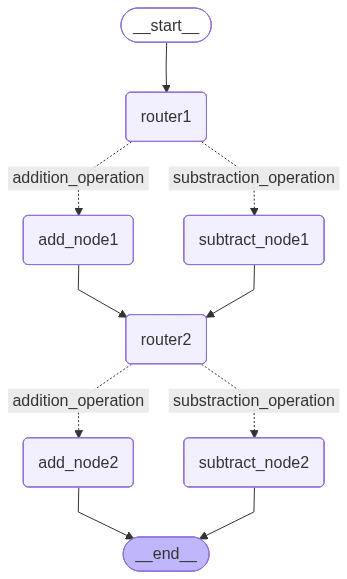

In [43]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [50]:
initial_state_1=AgentState(number1=10, operation="-", number2=5, number3=7, number4=5)


In [51]:
print(app.invoke(initial_state_1))

{'operation': '-', 'number1': 10, 'number2': 5, 'number3': 7, 'number4': 5, 'final_number1': 5, 'final_number2': 2}
